<a href="https://colab.research.google.com/github/DiegoSamanezDenis/COMP472-Brain-Tumor-MRI-CNN/blob/main/notebooks/Binary_Classification_br35h.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import os

files.upload()

!mkdir -p ~/.kaggle/
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ahmedhamada0/brain-tumor-detection

!unzip -q brain-tumor-detection.zip -d dataset_br35h


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ahmedhamada0/brain-tumor-detection
License(s): copyright-authors
  0% 0.00/84.0M [00:00<?, ?B/s]
100% 84.0M/84.0M [00:00<00:00, 1.71GB/s]


In [2]:
# ── Verify dataset structure ──────────────────────────────────────────
# ImageFolder expects: dataset_br35h/<class_name>/*.jpg
# If there's an extra nesting level, adjust DATA_ROOT accordingly.

import pathlib

DATA_ROOT = 'dataset_br35h'
top_level = sorted(os.listdir(DATA_ROOT))
print(f'Top-level contents of {DATA_ROOT}/ ({len(top_level)} items):')
for item in top_level[:10]:
    print(f'  {item}/')
if len(top_level) > 10:
    print(f'  ... and {len(top_level) - 10} more')

# If the zip has one wrapper folder, descend into it automatically
if len(top_level) == 1 and os.path.isdir(os.path.join(DATA_ROOT, top_level[0])):
    DATA_ROOT = os.path.join(DATA_ROOT, top_level[0])
    print(f'\n⚠️  Single subfolder detected — using DATA_ROOT = "{DATA_ROOT}"')
    adjusted = sorted(os.listdir(DATA_ROOT))
    print(f'Adjusted contents ({len(adjusted)} items):')
    for item in adjusted[:10]:
        print(f'  {item}/')
    if len(adjusted) > 10:
        print(f'  ... and {len(adjusted) - 10} more')

Top-level contents of dataset_br35h/ (4 items):
  Br35H-Mask-RCNN/
  no/
  pred/
  yes/


## Filter to Binary Classes Only
For **binary classification**, we only want 'yes' (tumor) and 'no' (no tumor) folders.
This cell creates a filtered dataset directory with only these two classes.

In [3]:
import shutil

# Create a new filtered directory for binary classification
BINARY_ROOT = 'dataset_br35h_binary'

# Check what folders exist in the dataset
all_folders = sorted([f for f in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, f))])
print(f'Found folders: {all_folders}')

# Define the two classes we want for binary classification
BINARY_CLASSES = ['no', 'yes']  # 0=no tumor, 1=tumor present

# Check if we need to filter
if set(all_folders) != set(BINARY_CLASSES):
    print(f'\n⚠️  Dataset contains {len(all_folders)} classes, but we only need 2 for binary classification.')
    print(f'Creating filtered dataset with only: {BINARY_CLASSES}')

    # Create filtered directory structure
    os.makedirs(BINARY_ROOT, exist_ok=True)

    for class_name in BINARY_CLASSES:
        src = os.path.join(DATA_ROOT, class_name)
        dst = os.path.join(BINARY_ROOT, class_name)

        if os.path.exists(src):
            if not os.path.exists(dst):
                shutil.copytree(src, dst)
            num_images = len([f for f in os.listdir(dst) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f'  ✓ {class_name}: {num_images} images')
        else:
            print(f'  ✗ WARNING: "{class_name}" folder not found in dataset!')

    # Use the filtered directory
    DATA_ROOT = BINARY_ROOT
    print(f'\nUsing filtered DATA_ROOT: {DATA_ROOT}')
else:
    print(f'\n✓ Dataset already contains only binary classes: {all_folders}')

Found folders: ['Br35H-Mask-RCNN', 'no', 'pred', 'yes']

⚠️  Dataset contains 4 classes, but we only need 2 for binary classification.
Creating filtered dataset with only: ['no', 'yes']
  ✓ no: 1500 images
  ✓ yes: 1500 images

Using filtered DATA_ROOT: dataset_br35h_binary


In [5]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/brain_tumor_weights'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Weights will be saved to: {SAVE_DIR}')

Mounted at /content/drive
Weights will be saved to: /content/drive/MyDrive/brain_tumor_weights


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import time
import json
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [7]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Dataset Splitting
We load the dataset twice (one per transform set) so that `Subset`
inherits the correct transforms for train vs. val/test.

In [8]:
def get_stratified_split_indices(targets, val_split=0.15, test_split=0.15):
  train_idx, temp_idx = train_test_split(
      np.arange(len(targets)),
      test_size=(val_split + test_split),
      stratify=targets,
      random_state=42
  )
  temp_targets = [targets[i] for i in temp_idx]
  val_idx, test_idx = train_test_split(
      temp_idx,
      test_size=test_split / (val_split + test_split),
      stratify=temp_targets,
      random_state=42
  )
  return train_idx, val_idx, test_idx

In [9]:
# Two ImageFolder instances — same images, different transforms
ds_train_aug = datasets.ImageFolder(DATA_ROOT, transform=train_transforms)
ds_eval      = datasets.ImageFolder(DATA_ROOT, transform=eval_transforms)

train_idx, val_idx, test_idx = get_stratified_split_indices(ds_eval.targets)

In [10]:
# Build subsets with correct transforms
train_set = Subset(ds_train_aug, train_idx)   # augmented
val_set   = Subset(ds_eval,      val_idx)     # clean
test_set  = Subset(ds_eval,      test_idx)    # clean

In [11]:
NUM_CLASSES = len(ds_eval.classes)
CLASS_NAMES = ds_eval.classes

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Total images : {len(ds_eval)}')
print(f'Train / Val / Test : {len(train_set)} / {len(val_set)} / {len(test_set)}')

Classes (2): ['no', 'yes']
Total images : 3000
Train / Val / Test : 2100 / 450 / 450


In [12]:
NUM_WORKERS = 2  # safe default for Colab

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

dataloaders = {'train': train_loader, 'val': val_loader}

# Training & Evaluation Pipeline

In [13]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, device,
                num_epochs=25, save_path=None):
    """
    Train with validation, LR scheduling, history tracking, and best-weight saving.

    Args:
        scheduler: LR scheduler (stepped per epoch on val loss)
        dataloaders: dict with 'train' and 'val' keys
        save_path: .pth path to save best weights (also saves _history.json)
    Returns:
        model (best weights loaded), history dict
    """
    model = model.to(device)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [],   'val_acc': [],
        'lr': []
    }

    since = time.time()

    for epoch in range(num_epochs):
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        print(f'Epoch {epoch + 1}/{num_epochs}  (lr={current_lr:.2e})')
        print('-' * 45)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=f'  {phase}', leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc  = (running_corrects.double() / len(dataloaders[phase].dataset)).item()

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f'  {phase:5s}  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            if phase == 'val':
                # Step the scheduler on validation loss
                scheduler.step(epoch_loss)

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    if save_path:
                        torch.save(best_model_wts, save_path)
                        print(f'  ✓ New best model saved ({save_path})')
        print()

    elapsed = time.time() - since
    print(f'Training complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)

    if save_path:
        history_path = save_path.replace('.pth', '_history.json')
        with open(history_path, 'w') as f:
            json.dump(history, f)
        print(f'History saved to {history_path}')

    return model, history

In [14]:
def evaluate_model(model, test_loader, class_names, device):
    """Run evaluation on test set. Returns confusion matrix, labels, preds."""
    model = model.to(device).eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Evaluating', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds,
                                target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    return cm, all_labels, all_preds

In [15]:
def plot_training_curves(history, title=''):
    """Plot loss, accuracy, and learning rate curves."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-', label='Validation')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train')
    axes[1].plot(epochs, history['val_acc'],   'r-', label='Validation')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if 'lr' in history:
        axes[2].plot(epochs[:len(history['lr'])], history['lr'], 'g-')
        axes[2].set_title(f'{title} — Learning Rate')
        axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
        axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)
    else:
        axes[2].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, class_names, title=''):
    """Plot confusion matrix as a heatmap."""
    fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 0.5),
                                     max(6, len(class_names) * 0.4)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{title} — Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Helper: Build model + optimizer + scheduler

In [16]:
def build_experiment(model, lr=1e-3):
    """Return criterion, optimizer, and scheduler for a model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    return criterion, optimizer, scheduler

## Model Definitions
Set `USE_PRETRAINED = True` (recommended) for transfer learning,
or `False` to train from scratch as in the original notebook.

In [17]:
USE_PRETRAINED = False  # ← flip to True for much better results

def _weights(flag):
    """Return pretrained weights arg or None."""
    return 'IMAGENET1K_V1' if flag else None

# ── ResNet18 ──────────────────────────────────────────────────────────
model_resnet = models.resnet18(weights=_weights(USE_PRETRAINED))
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, NUM_CLASSES)
criterion_resnet, optimizer_resnet, scheduler_resnet = build_experiment(model_resnet)
print(f'ResNet18    params: {sum(p.numel() for p in model_resnet.parameters() if p.requires_grad):,}')

# ── MobileNetV2 ──────────────────────────────────────────────────────
model_mobilenet = models.mobilenet_v2(weights=_weights(USE_PRETRAINED))
model_mobilenet.classifier[1] = nn.Linear(model_mobilenet.last_channel, NUM_CLASSES)
criterion_mobile, optimizer_mobile, scheduler_mobile = build_experiment(model_mobilenet)
print(f'MobileNetV2 params: {sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad):,}')

# ── VGG16 ─────────────────────────────────────────────────────────────
model_vgg = models.vgg16(weights=_weights(USE_PRETRAINED))
model_vgg.classifier[6] = nn.Linear(4096, NUM_CLASSES)
criterion_vgg, optimizer_vgg, scheduler_vgg = build_experiment(model_vgg)
print(f'VGG16       params: {sum(p.numel() for p in model_vgg.parameters() if p.requires_grad):,}')


ResNet18    params: 11,177,538
MobileNetV2 params: 2,226,434
VGG16       params: 134,268,738


# Train ResNet18 (Scratch) — br35h

In [18]:
model_resnet, history_resnet = train_model(
    model_resnet, criterion_resnet, optimizer_resnet, scheduler_resnet,
    dataloaders, device,
    num_epochs=20,
    save_path=os.path.join(SAVE_DIR, 'resnet18_br35h.pth')
)

Epoch 1/20  (lr=1.00e-03)
---------------------------------------------


  train:   0%|          | 0/66 [00:00<?, ?it/s]

  train  Loss: 0.6400  Acc: 0.7010


  val:   0%|          | 0/15 [00:00<?, ?it/s]

  val    Loss: 0.5583  Acc: 0.7422
  ✓ New best model saved (/content/drive/MyDrive/brain_tumor_weights/resnet18_br35h.pth)

Epoch 2/20  (lr=1.00e-03)
---------------------------------------------


...

  val    Loss: 0.0937  Acc: 0.9689

Epoch 20/20  (lr=5.00e-04)
---------------------------------------------


  train:   0%|          | 0/66 [00:00<?, ?it/s]

  train  Loss: 0.0832  Acc: 0.9733


  val:   0%|          | 0/15 [00:00<?, ?it/s]

  val    Loss: 0.0807  Acc: 0.9800
  ✓ New best model saved (/content/drive/MyDrive/brain_tumor_weights/resnet18_br35h.pth)

Training complete in 5m 16s
Best val Acc: 0.9800
History saved to /content/drive/MyDrive/brain_tumor_weights/resnet18_br35h_history.json


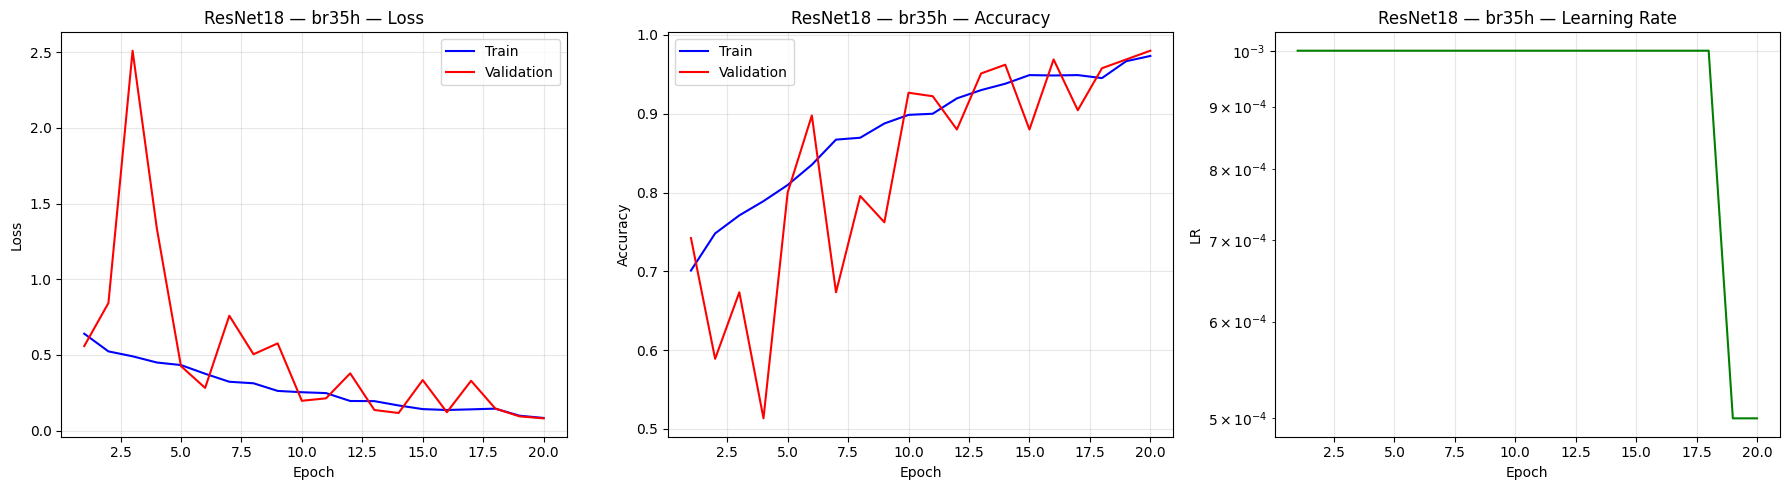

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

          no       0.97      0.98      0.98       225
         yes       0.98      0.97      0.98       225

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



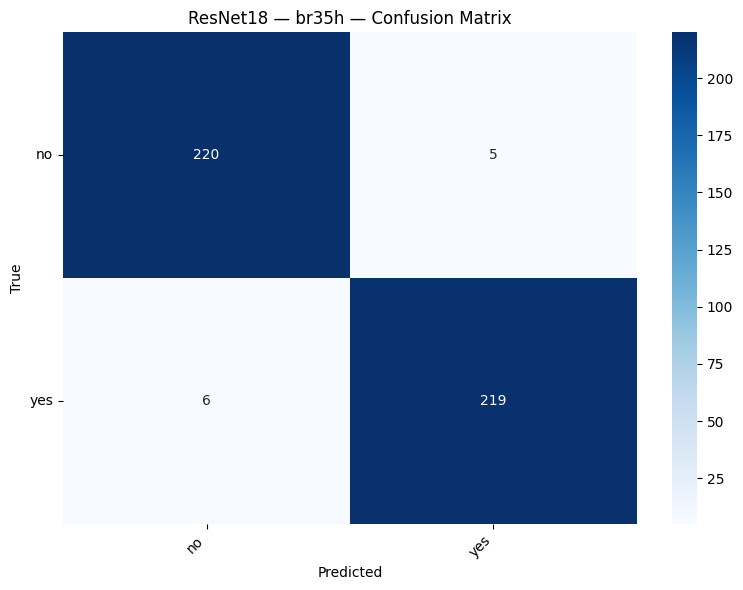

In [19]:
plot_training_curves(history_resnet, title='ResNet18 — br35h')
cm_resnet, _, _ = evaluate_model(model_resnet, test_loader, CLASS_NAMES, device)
plot_confusion_matrix(cm_resnet, CLASS_NAMES, title='ResNet18 — br35h')

# Train MobileNetV2 (Scratch) — br35h

In [20]:
model_mobilenet, history_mobilenet = train_model(
    model_mobilenet, criterion_mobile, optimizer_mobile, scheduler_mobile,
    dataloaders, device,
    num_epochs=20,
    save_path=os.path.join(SAVE_DIR, 'mobilenetv2_br35h.pth')
)

Epoch 1/20  (lr=1.00e-03)
---------------------------------------------


  train:   0%|          | 0/66 [00:00<?, ?it/s]

  train  Loss: 0.5931  Acc: 0.6786


  val:   0%|          | 0/15 [00:00<?, ?it/s]

  val    Loss: 0.6376  Acc: 0.6089
  ✓ New best model saved (/content/drive/MyDrive/brain_tumor_weights/mobilenetv2_br35h.pth)

Epoch 2/20  (lr=1.00e-03)
---------------------------------------------


...

  val    Loss: 0.1641  Acc: 0.9444

Epoch 20/20  (lr=1.00e-03)
---------------------------------------------


  train:   0%|          | 0/66 [00:00<?, ?it/s]

  train  Loss: 0.0963  Acc: 0.9595


  val:   0%|          | 0/15 [00:00<?, ?it/s]

  val    Loss: 0.1475  Acc: 0.9467

Training complete in 5m 18s
Best val Acc: 0.9622
History saved to /content/drive/MyDrive/brain_tumor_weights/mobilenetv2_br35h_history.json


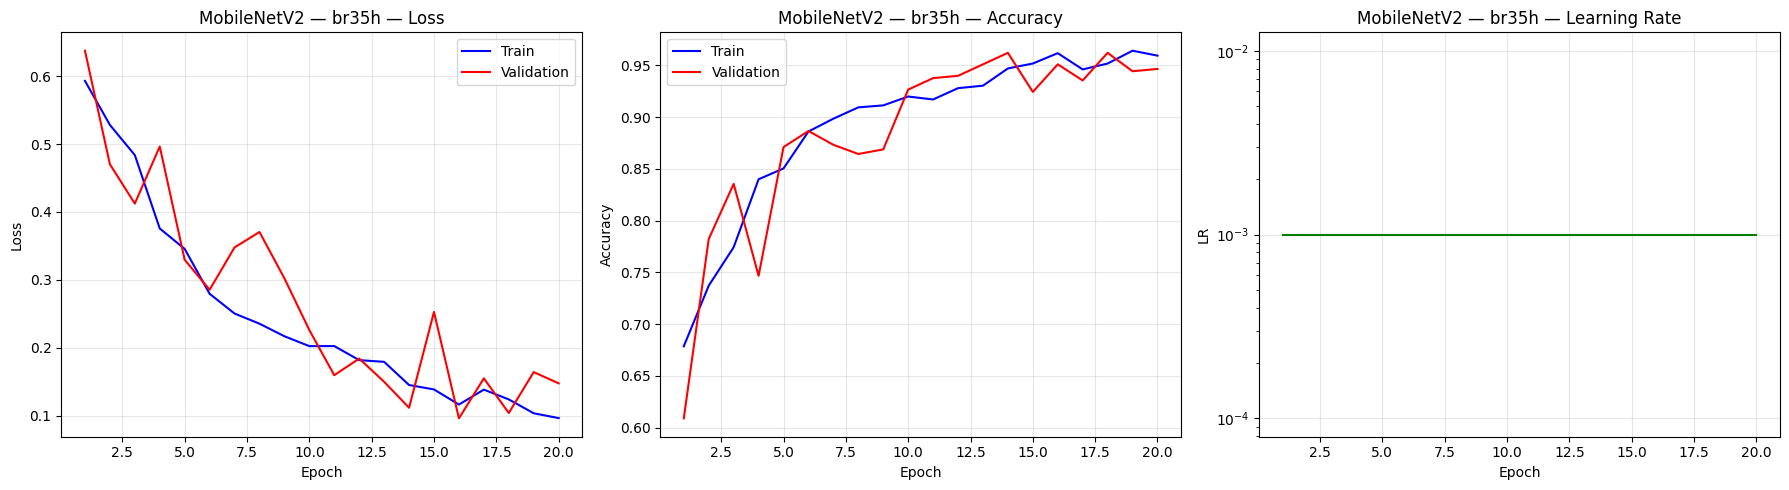

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.98      0.96       225
         yes       0.98      0.95      0.96       225

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



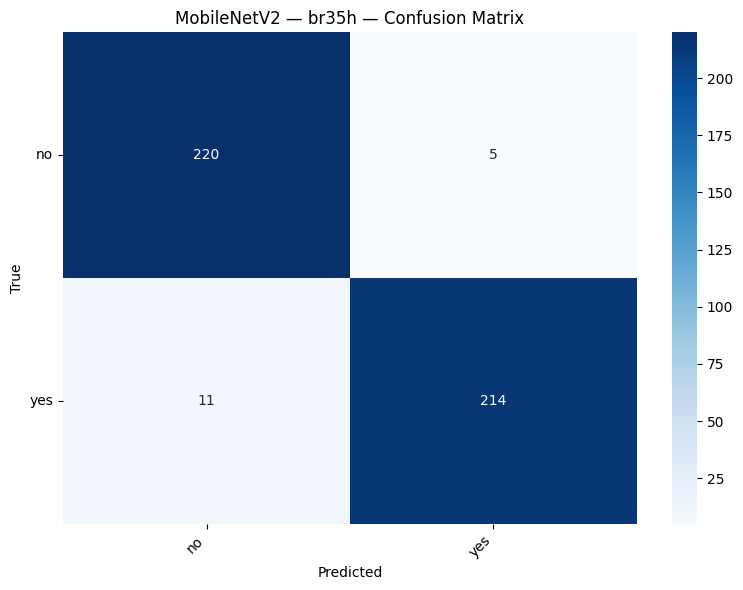

In [21]:
plot_training_curves(history_mobilenet, title='MobileNetV2 — br35h')
cm_mobile, _, _ = evaluate_model(model_mobilenet, test_loader, CLASS_NAMES, device)
plot_confusion_matrix(cm_mobile, CLASS_NAMES, title='MobileNetV2 — br35h')

# Train VGG16 (Scratch) — br35h

In [22]:
model_vgg, history_vgg = train_model(
    model_vgg, criterion_vgg, optimizer_vgg, scheduler_vgg,
    dataloaders, device,
    num_epochs=20,
    save_path=os.path.join(SAVE_DIR, 'vgg16_br35h.pth')
)

Epoch 1/20  (lr=1.00e-03)
---------------------------------------------


  train:   0%|          | 0/66 [00:00<?, ?it/s]

  train  Loss: 1.7446  Acc: 0.4990


  val:   0%|          | 0/15 [00:00<?, ?it/s]

  val    Loss: 0.6932  Acc: 0.5000
  ✓ New best model saved (/content/drive/MyDrive/brain_tumor_weights/vgg16_br35h.pth)

Epoch 2/20  (lr=1.00e-03)
---------------------------------------------


...

  val    Loss: 0.6931  Acc: 0.5000

Epoch 20/20  (lr=1.25e-04)
---------------------------------------------


  train:   0%|          | 0/66 [00:00<?, ?it/s]

  train  Loss: 0.6933  Acc: 0.5024


  val:   0%|          | 0/15 [00:00<?, ?it/s]

  val    Loss: 0.6931  Acc: 0.5000

Training complete in 11m 45s
Best val Acc: 0.5000
History saved to /content/drive/MyDrive/brain_tumor_weights/vgg16_br35h_history.json


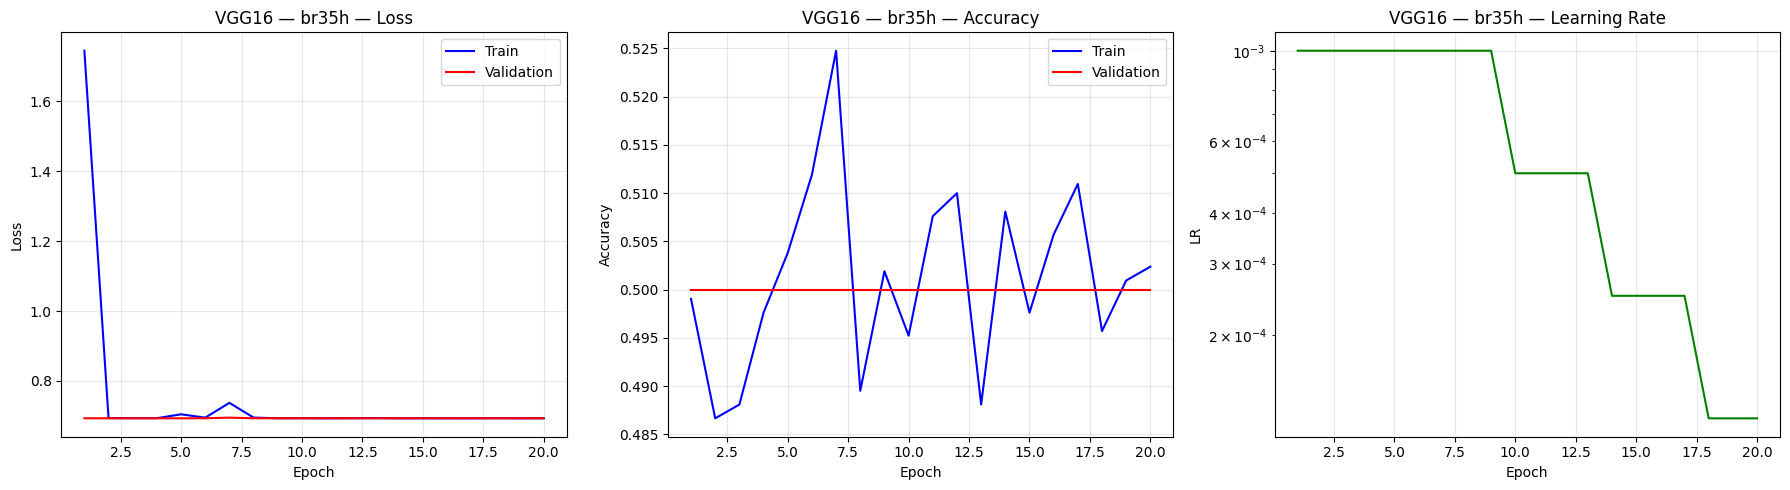

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

          no       0.50      1.00      0.67       225
         yes       0.00      0.00      0.00       225

    accuracy                           0.50       450
   macro avg       0.25      0.50      0.33       450
weighted avg       0.25      0.50      0.33       450



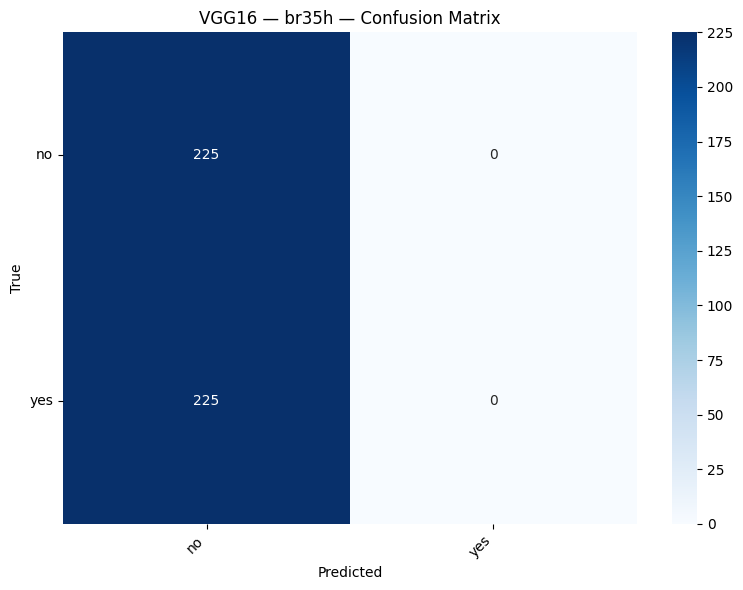

In [23]:
plot_training_curves(history_vgg, title='VGG16 — br35h')
cm_vgg, _, _ = evaluate_model(model_vgg, test_loader, CLASS_NAMES, device)
plot_confusion_matrix(cm_vgg, CLASS_NAMES, title='VGG16 — br35h')

# Reload Saved Model & History (Example)
Use this to reload weights after a runtime restart without retraining.

In [24]:
# model_reloaded = models.resnet18(weights=None)
# model_reloaded.fc = nn.Linear(model_reloaded.fc.in_features, NUM_CLASSES)
# model_reloaded.load_state_dict(
#     torch.load(os.path.join(SAVE_DIR, 'resnet18_br35h.pth'), map_location=device)
# )
# model_reloaded.to(device).eval()
#
# with open(os.path.join(SAVE_DIR, 'resnet18_br35h_history.json')) as f:
#     history_reloaded = json.load(f)
# plot_training_curves(history_reloaded, title='ResNet18 — br35h (reloaded)')